<a href="https://colab.research.google.com/github/nando-cezar/mcer-infrastructure/blob/develop/mcer_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#MCER


###Env config

In [326]:
!pip install openmeteo-requests
!pip install requests-cache retry-requests
!pip install pandas matplotlib seaborn numpy geopandas
!pip install --upgrade matplotlib

### ⚙️ BLOCO 1 — Coleta de dados **técnicos**


In [327]:
# ---------------------------
# DADOS TÉCNICOS DOS EQUIPAMENTOS (ajustados)
# ---------------------------

# Residential Solar Panels 595 W Mono
PAINEL_SOLAR = {
    "potencia_kwp": 0.595,                      # 595 W ≈ 0.595 kW
    "temperatura_referencia": 25.0,            # °C
    "eficiencia": 0.1833,                      # ~18.33% como CS6K-300MS :contentReference[oaicite:3]{index=3}
    "coef_temperatura": -0.0039,               # −0.39%/°C como CS6K-300MS :contentReference[oaicite:4]{index=4}
    "vida_util": 25,                           # anos (padrão residencial)
    "custo_equipamento": 3500,                 # ~R$3.500 por painel 595 W (estimativa Brasil)
    "custo_instalacao": 600,                   # ~R$600 por painel (estrutura + montagem) – estimativa
    "quantidade_paineis": 20,                  # para sistema de ~11.9 kW
    "area_m2": 2.0 * 20,                        # estimativa ~2 m² por módulo → total ~40 m²
    "NOCT": 45.0                               # °C (aprox.) como referência de NMOT/NOCT típica
}

# HUIZHITENGDA - 10kW Vertical
TURBINA_EOLICA = {
    "cut_in_speed": 2.0,               # m/s (velocidade iniciada)
    "rated_speed": 10.0,               # m/s (nominal)
    "cut_out_speed": 40.0,             # m/s (segura/limite)
    "potencia_nominal": 10.0,          # kW (10000 W)
    "rotor_area": 0.972,               # m² (π*(0.55/2)^2)
    "vida_util": 20,                   # anos (padrão)
    "custo_equipamento": 2624,         # R$ por turbina
    "custo_instalacao": 2000,          # R$ (não informado)
    "quantidade_turbinas": 20
}

###🌦️ BLOCO 2 — Núcleo climático e normalização física


In [328]:
import pandas as pd
import numpy as np
import requests_cache
import logging
import openmeteo_requests
from datetime import datetime
from typing import Dict, Optional
from scipy.stats import mode

# ================================================================
# BLINDAGEM TEMPORAL + VALIDAÇÃO FÍSICA (REFINADO)
# ================================================================
def ensure_no_date_ambiguity(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove ambiguidade entre 'date' e índice temporal.
    - Mantém apenas UMA coluna 'date' (datetime, hora exata).
    - Nunca deixa índice nomeado 'date'.
    - Ordena e limpa NaT.
    """
    df = df.copy()

    # 1) Reset se 'date' estiver em nomes do índice
    if "date" in getattr(df.index, "names", []) or getattr(df.index, "name", None) == "date":
        df = df.reset_index()
        if "date" in df.columns and not np.issubdtype(df["date"].dtype, np.datetime64):
            # se veio como objeto/string
            df["date"] = pd.to_datetime(df["date"], errors="coerce")

    # 2) Remover duplicata de colunas 'date'
    if "date" in df.columns[df.columns.duplicated()]:
        df = df.loc[:, ~df.columns.duplicated()]

    # 3) Criar/normalizar 'date'
    if "date" not in df.columns:
        if isinstance(df.index, pd.DatetimeIndex):
            df["date"] = df.index
        else:
            raise ValueError("DataFrame sem índice temporal e sem coluna 'date'.")
    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.floor("h")

    # 4) Limpeza e ordenação
    df.dropna(subset=["date"], inplace=True)
    if isinstance(df.index, pd.DatetimeIndex):
        df = df.reset_index(drop=True)
    df.sort_values("date", inplace=True)
    df.reset_index(drop=True, inplace=True)
    df.index.name = None
    return df


def validate_physical_ranges(df: pd.DataFrame):
    """
    Valida faixas físicas típicas (não corrige dados, apenas loga warnings).
    As radiações estão em kWh/m² por hora (após normalização).
    """
    checks = {
        "temperature_2m": (-80, 70),                # °C
        "relative_humidity_2m": (0, 100),           # %
        "wind_speed_10m": (0, 80),                  # m/s
        "wind_speed_100m": (0, 100),                # m/s
        "wind_direction_10m": (0, 360),             # °
        "wind_direction_100m": (0, 360),            # °
        "shortwave_radiation": (0, 1.5),            # kWh/m²-h (pico ~1.2 em trópicos)
        "direct_radiation": (0, 1.5),               # kWh/m²-h
        "diffuse_radiation": (0, 1.5),              # kWh/m²-h
        "global_tilted_irradiance": (0, 1.8),       # kWh/m²-h (POA pode exceder GHI em baixos ângulos)
        "cloud_cover": (0, 1),                      # fração [0,1] (normalizada abaixo)
        "albedo": (0, 1),                           # fração [0,1]
        "surface_pressure": (800, 1100),            # hPa (ajuste correto; antes estava 0–100)
        "precipitation": (0, 200),                  # mm/h (valor alto mas preserva extremos)
        "rain": (0, 200),                           # mm/h
        "snow_depth": (0, 5000),                    # mm
    }

    for col, (low, high) in checks.items():
        if col in df.columns:
            s = pd.to_numeric(df[col], errors="coerce")
            invalid_low = (s < low).sum()
            invalid_high = (s > high).sum()
            if invalid_low or invalid_high:
                logger.warning(f"[Validação física] {col}: {invalid_low} abaixo ({low}), {invalid_high} acima ({high})")


# ================================================================
# NORMALIZAÇÃO OPEN-METEO (RIGOR UNITÁRIO + PERFORMANCE)
# ================================================================
def normalize_open_meteo_hourly(hourly_data, unit_ids, hourly_units=None, response=None):
    """
    Converte a saída Open-Meteo p/ um DataFrame fisicamente coerente:
      - Velocidades → m/s
      - Direções → [0,360)
      - Radiações (W/m² médios na hora) → kWh/m²-h (×0.001×dt_hours)
      - Umidade relativa → %
      - Nebulosidade → fração [0,1]
      - Albedo → fração [0,1]
      - Pressão → hPa (mantido)
    Mantém interface/assinatura original.
    """
    df = hourly_data.copy()
    df = df.astype({c: float for c in df.columns if np.issubdtype(df[c].dtype, np.number)}, copy=False)

    # Δt (h) preciso
    dt_hours = 1.0
    if response is not None:
        try:
            interval_sec = response.Hourly().Interval()
            dt_hours = float(interval_sec) / 3600.0
        except Exception as e:
            logger.warning(f"Falha ao detectar intervalo temporal: {e}")
            dt_hours = 1.0

    def _to_ms(x, unit):
        if unit in ("km/h", "kmh"):   # OM usa "km/h"
            return x / 3.6
        if unit == "mph":
            return x * 0.44704
        return x

    def _rad_to_kwhpm2(x):
        # OM retorna média W/m² na hora → energia na hora = W/m² * h
        return x * 0.001 * dt_hours

    out = {}
    # Tentar descobrir unidades originais reportadas pela API
    unit_map = {}
    try:
        if hourly_units and isinstance(hourly_units, dict):
            unit_map = dict(hourly_units)
    except Exception:
        unit_map = {}

    for col in df.columns:
        uid = unit_ids.get(col)
        series = pd.to_numeric(df[col], errors="coerce")

        if uid == 24:  # vento
            out[col] = _to_ms(series, unit_map.get(col, "km/h"))
        elif uid == 5:  # direção vento
            out[col] = (series % 360.0).astype(float)
        elif uid == 39:  # radiação
            out[col] = _rad_to_kwhpm2(series)
        elif uid == 35:  # % compartilhado (umidade) / fração (cloud_cover)
            if "humidity" in col:
                out[col] = np.clip(series, 0, 100)
            elif "cloud" in col:
                # OM pode vir em %; convertemos para fração robustamente
                if np.nanmax(series.values) > 1.0:
                    out[col] = np.clip(series / 100.0, 0.0, 1.0)
                else:
                    out[col] = np.clip(series, 0.0, 1.0)
            else:
                out[col] = np.clip(series, 0, 100)
        elif uid == 0:  # albedo
            # Já pode vir em %; normalizar para fração
            if np.nanmax(series.values) > 1.0:
                out[col] = np.clip(series / 100.0, 0.0, 1.0)
            else:
                out[col] = np.clip(series, 0.0, 1.0)
        elif uid in (1, 16, 29, 32):  # temperatura, pressão, neve, precipitação
            out[col] = pd.to_numeric(series, errors="coerce")
        else:
            # Colunas desconhecidas: passa adiante sem alterar
            out[col] = series

    out_df = pd.DataFrame(out, index=hourly_data.index)
    return out_df



# ================================================================
# CLIENTE OPEN-METEO (ROBUSTO + COERÊNCIA TEMPORAL)
# ================================================================
def search_info_weather(
    latitude, longitude, start_date, end_date, timezone,
    cache_path=".cache", cache_expire_hours=-1,
    retries=3, backoff=0.3, normalize=True
):
    """
    Busca dados horários (arquivo histórico) com:
      - cache (requests-cache)
      - retry/backoff
      - normalização de unidades (opcional)
      - coerência temporal (índice → 'date')
    Retorna: {'data': DataFrame, 'units': dict}
    """
    # Sessão com cache
    cache_session = requests_cache.CachedSession(
        cache_path,
        expire_after=None if cache_expire_hours < 0 else pd.Timedelta(hours=cache_expire_hours)
    )

    # Retry/Backoff simples usando requests.adapters e urllib3 Retry
    from requests.adapters import HTTPAdapter
    try:
        from urllib3.util.retry import Retry
        retry_cfg = Retry(
            total=max(0, int(retries)),
            read=max(0, int(retries)),
            connect=max(0, int(retries)),
            backoff_factor=float(backoff),
            status_forcelist=(429, 500, 502, 503, 504),
            allowed_methods=frozenset(["GET"]),
            raise_on_status=False,
        )
        adapter = HTTPAdapter(max_retries=retry_cfg)
        cache_session.mount("https://", adapter)
        cache_session.mount("http://", adapter)
    except Exception:
        # fallback: sem retry avançado
        pass

    openmeteo = openmeteo_requests.Client(session=cache_session)

    url = "https://archive-api.open-meteo.com/v1/archive"
    hourly_vars = [
        "temperature_2m", "relative_humidity_2m", "precipitation", "rain",
        "snow_depth", "wind_speed_10m", "wind_speed_100m", "wind_direction_10m",
        "wind_direction_100m", "cloud_cover", "shortwave_radiation",
        "direct_radiation", "diffuse_radiation", "global_tilted_irradiance",
        "albedo", "surface_pressure"
    ]

    unit_ids = {
        "temperature_2m": 1,
        "relative_humidity_2m": 35,
        "precipitation": 32,
        "rain": 32,
        "snow_depth": 29,
        "wind_speed_10m": 24,
        "wind_speed_100m": 24,
        "wind_direction_10m": 5,
        "wind_direction_100m": 5,
        "cloud_cover": 35,
        "shortwave_radiation": 39,
        "direct_radiation": 39,
        "diffuse_radiation": 39,
        "global_tilted_irradiance": 39,
        "albedo": 0,
        "surface_pressure": 16
    }

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": hourly_vars,
        "timezone": timezone,
        "temperature_unit": "celsius",
        "wind_speed_unit": "kmh",       # OM retorna como km/h (convertido para m/s)
        "precipitation_unit": "mm",
    }

    logger.info(f"Consultando Open-Meteo: {latitude}, {longitude}, {start_date} → {end_date}")

    try:
        response = openmeteo.weather_api(url, params=params)[0]
    except Exception as e:
        raise ConnectionError(f"Erro na conexão com Open-Meteo: {e}")

    hourly = response.Hourly()
    data, units = {}, {}

    for i, var_name in enumerate(hourly_vars):
        try:
            var = hourly.Variables(i)
            data[var_name] = var.ValuesAsNumpy()
            units[var_name] = unit_ids.get(var_name)
        except Exception as e:
            logger.warning(f"Falha ao extrair variável {var_name}: {e}")
            continue

    # Eixo temporal
    try:
        start = pd.to_datetime(hourly.Time(), unit="s", utc=True)
        end = pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True)
        step = pd.Timedelta(seconds=hourly.Interval())
        times = pd.date_range(start=start, end=end, freq=step, inclusive="left")
    except Exception as e:
        raise ValueError(f"Falha ao construir índice temporal: {e}")

    if not data:
        raise ValueError("Nenhuma variável horária retornada pela API.")

    # Aparar colunas ao comprimento modal (evita desalinhamento)
    lengths = [len(v) for v in data.values()]
    modal_len = max(set(lengths), key=lengths.count)
    for k in list(data.keys()):
        v = np.asarray(data[k])
        if len(v) != modal_len:
            data[k] = v[:modal_len]
    times = times[:modal_len]

    df = pd.DataFrame(data, index=pd.DatetimeIndex(times, name="time"))
    df["latitude"] = float(latitude)
    df["longitude"] = float(longitude)

    # Normalização de unidades
    if normalize:
        try:
            hourly_units = dict(response.Hourly().Units())
        except Exception:
            hourly_units = {}
        df = normalize_open_meteo_hourly(df, unit_ids, hourly_units=hourly_units, response=response)

    # Validação física + blindagem temporal
    validate_physical_ranges(df)
    df = ensure_no_date_ambiguity(df)

    logger.info(f"Dados obtidos e normalizados: {df.shape[0]} registros × {df.shape[1]} variáveis.")
    return {"data": df, "units": unit_ids}

###☀️🍃 BLOCO 3 — Modelos físicos de geração (solar e eólica)


In [329]:
import numpy as np
import pandas as pd
from math import pi
from typing import Dict, Optional, List, Tuple
from scipy.optimize import brentq
from scipy.special import gamma
from scipy.integrate import quad

# ============================================================
# SOLAR (PV) — Físico robusto com Hay–Davies + Faiman + IAM
# ============================================================
def calcular_energia_solar(
    hourly_data: dict,
    painel: dict,
    performance_ratio: float = 1.0,
    tilt_angle: float | None = None,
    degradacao_anual: float = 0.0,
    soiling_rate_per_hour: float = 0.005 / 24.0,  # fração/h
    soiling_cap: float = 0.20,
    rain_wash_efficiency: float = 1.0,
):
    """
    Cálculo PV com:
      - Preferência por GTI; fallback POA (GHI/DNI/DHI + albedo)
      - IAM (ASHRAE b0)
      - Temperatura da célula por Faiman (U0 + U1 * v)
      - PR composto + clipping DC/AC
      - Penalização por neve
    Retorna: (producao_anual_kwh, fator_capacidade, df_horario, energia_vida_kwh)
    """
    if not isinstance(hourly_data, dict) or "data" not in hourly_data:
        raise ValueError("hourly_data deve conter {'data': DataFrame, 'units': dict}")

    df = pd.DataFrame(hourly_data["data"]).copy()
    if df.empty:
        raise ValueError("Dados horários vazios.")

    # --------------------------
    # 1) Irradiância no plano do módulo (kWh/m²) — Hay–Davies
    # --------------------------
    prefer_gti = "global_tilted_irradiance" in df.columns
    if prefer_gti:
        # GTI já vem no plano do arranjo (kWh/m² na hora)
        G_poa = pd.to_numeric(df["global_tilted_irradiance"], errors="coerce").fillna(0.0).clip(lower=0.0)
        cos_ti = 1.0
    else:
        # 🔧 fontes: usar GHI, DNI, DHI com transposição Hay–Davies
        GHI = pd.to_numeric(df.get("shortwave_radiation", 0.0), errors="coerce").fillna(0.0).clip(lower=0.0)
        DNI = pd.to_numeric(df.get("direct_radiation", 0.0), errors="coerce").fillna(0.0).clip(lower=0.0)
        DHI = pd.to_numeric(df.get("diffuse_radiation", 0.0), errors="coerce").fillna(0.0).clip(lower=0.0)
        alb = pd.to_numeric(df.get("albedo", 0.2), errors="coerce").fillna(0.2).clip(0.0, 1.0)

        # Geometria solar mínima (sem longitude)
        lat_deg = float(df.get("latitude", 0.0))
        lat = np.deg2rad(lat_deg)
        t_index = pd.to_datetime(df["date"] if "date" in df.columns else df.index)
        doy = t_index.dayofyear.values
        B = 2 * np.pi * (doy - 1) / 365.0
        # declinação (radianos)
        decl = (
            0.006918
            - 0.399912 * np.cos(B) + 0.070257 * np.sin(B)
            - 0.006758 * np.cos(2 * B) + 0.000907 * np.sin(2 * B)
            - 0.002697 * np.cos(3 * B) + 0.00148 * np.sin(3 * B)
        )
        # hora solar aproximada (sem equação do tempo e longitude): bom o suficiente para transposição média
        h = (t_index.hour.values - 12) * np.pi / 12.0

        cos_z = np.clip(np.sin(lat) * np.sin(decl) + np.cos(lat) * np.cos(decl) * np.cos(h), 0.0, 1.0)
        cos_z = np.where(cos_z <= 0, 1e-6, cos_z)  # 🔧 evita divisão por 0 na anisotropia
        z = np.arccos(np.clip(cos_z, 0.0, 1.0))

        # Inclinação do módulo
        tilt_deg = float(painel.get("tilt_angle", tilt_angle if tilt_angle is not None else 20.0))
        tilt = np.deg2rad(tilt_deg)

        # Azimute do módulo assumido para norte/sul conforme hemisfério (sinal de lat) — aproximação robusta
        # 🔧 mantém sem alterar interface/parâmetros
        # hemisfério sul → azimute ≈ norte (π); hemisfério norte → sul (0)
        az_mod = np.where(lat_deg < 0, np.pi, 0.0)

        # cosseno do ângulo de incidência no plano
        # aproximação: projeção no plano com azimute do painel
        sin_z = np.sqrt(np.clip(1.0 - cos_z**2, 0.0, 1.0))
        cos_az_diff = np.cos(az_mod) * np.cos(0.0) + np.sin(az_mod) * np.sin(0.0)  # diferença com azimute solar ~0
        cos_ti = np.clip(cos_z * np.cos(tilt) + sin_z * np.sin(tilt) * cos_az_diff, 0.0, 1.0)

        # Índice de anisotropia Hay-Davies (circumsolar): Ai = DNI / GHI
        Ai = np.where(GHI > 0.0, np.clip(DNI / GHI, 0.0, 1.0), 0.0)
        # Componente difusa transposta: Hd_tilt = DHI * [(1 - Ai) * (1+cosβ)/2 + Ai * (cosθ/ cosθz)]
        Hd_tilt = DHI * ((1.0 - Ai) * (1.0 + np.cos(tilt)) / 2.0 + Ai * (cos_ti / np.clip(cos_z, 1e-6, 1.0)))
        # Componente refletida do solo
        Hg_ref = GHI * alb * (1.0 - np.cos(tilt)) / 2.0
        # Componente direta no plano
        Hb_tilt = DNI * cos_ti

        G_poa = (Hb_tilt + Hd_tilt + Hg_ref).fillna(0.0).clip(lower=0.0)

    # IAM (ASHRAE)
    b0 = float(painel.get("iam_b0", 0.05))
    cos_ti_safe = np.clip(cos_ti, 1e-3, 1.0)
    IAM = np.clip(1.0 - b0 * (1.0 / cos_ti_safe - 1.0), 0.0, 1.0)
    if not prefer_gti:
        G_poa = G_poa * IAM  # 🔧 evita dupla penalização se GTI já vier no plano

    df["G_kwh_m2"] = G_poa

    # --------------------------
    # 2) Variáveis meteorológicas e vento para Faiman
    # --------------------------
    Tamb = pd.to_numeric(df.get("temperature_2m", 25.0), errors="coerce").fillna(25.0)
    v10 = pd.to_numeric(df.get("wind_speed_10m", np.nan), errors="coerce")
    v100 = pd.to_numeric(df.get("wind_speed_100m", np.nan), errors="coerce")
    if v10.notna().sum() > 0:
        v_wind = v10  # já em m/s
    elif v100.notna().sum() > 0:
        # 🔧 lei potência para 10 m (α=0.14)
        v_wind = (v100 / np.power(100 / 10, 0.14)).fillna(1.0)
    else:
        v_wind = pd.Series(1.0, index=df.index)  # 🔧 fallback físico mínimo

    rain = pd.to_numeric(df.get("rain", df.get("precipitation", 0.0)), errors="coerce").fillna(0.0)
    snow_mm = pd.to_numeric(df.get("snow_depth", 0.0), errors="coerce").fillna(0.0).clip(lower=0.0)

    # --------------------------
    # 3) Parâmetros do sistema e Faiman
    # --------------------------
    potencia_kwp = float(painel.get("potencia_kwp", 0.0))
    n_paineis = int(painel.get("quantidade_paineis", 1))
    if potencia_kwp <= 0 or n_paineis <= 0:
        raise ValueError("Parâmetros de potência ou quantidade de painéis inválidos.")
    kWp_total = potencia_kwp * n_paineis

    # 🔧 Faiman dimensional correto (U0 em W/m²K; U1 em W/m²K por (m/s))
    U0 = float(painel.get("faiman_U0", 25.0))
    U1 = float(painel.get("faiman_U1", 6.84))
    eta_ref = float(painel.get("module_efficiency_ref", painel.get("eficiencia", 0.18)))
    T_ref = float(painel.get("temperatura_referencia", 25.0))
    beta = float(painel.get("coef_temperatura", -0.0034))  # 1/K

    # Converte G_poa kWh/m² (na hora) → W/m² médio da hora (1 kWh/m²/h = 1000 W/m²)
    G_Wm2 = df["G_kwh_m2"] * 1000.0

    # 🔧 evita singularidade com vento zero
    denom = (U0 + U1 * v_wind.clip(lower=0.0)).replace(0.0, np.nan).fillna(U0)
    Tcell = Tamb + (G_Wm2 * (1.0 - eta_ref)) / denom
    temp_factor = (1.0 + beta * (Tcell - T_ref)).clip(0.5, 1.05)  # 🔧 clamp físico

    # --------------------------
    # 4) Soiling com lavagem proporcional à chuva
    # --------------------------
    soiling = np.zeros(len(df))
    acc = 0.0
    for i, r in enumerate(rain.values):
        if r > 0.0:
            # 🔧 lavagem proporcional (limitada)
            acc = acc * max(0.0, 1.0 - min(1.0, rain_wash_efficiency * (r / 1.0)))
        else:
            acc = min(soiling_cap, acc + soiling_rate_per_hour)
        soiling[i] = acc
    df["soiling"] = soiling

    # --------------------------
    # 5) PR + DC/AC clipping + neve
    # --------------------------
    inverter_eff = float(painel.get("inverter_efficiency", 0.98))
    system_losses = float(painel.get("system_losses", 0.03))
    mismatch_loss = float(painel.get("mismatch_loss", 0.02))
    cable_loss = float(painel.get("cable_loss", 0.01))

    PR = (
        float(performance_ratio)
        * temp_factor
        * (1.0 - df["soiling"])
        * inverter_eff
        * (1.0 - system_losses)
        * (1.0 - mismatch_loss)
        * (1.0 - cable_loss)
    ).clip(0.0, 1.0)

    # Potência DC média na hora (kW) = kWp_total * h_eq_sol * PR
    P_dc_kw = kWp_total * df["G_kwh_m2"] * PR

    # 🔧 clipping DC/AC consistente
    dc_ac = float(painel.get("dc_ac_ratio", 1.2))
    ac_limit_kw = float(painel.get("ac_power_kw", kWp_total / max(dc_ac, 1e-6)))
    P_ac_kw = np.minimum(np.clip(P_dc_kw, 0.0, None), ac_limit_kw)

    # 🔧 bloqueio de neve suave: 50 mm → ~100%
    snow_block = np.clip(snow_mm / 50.0, 0.0, 1.0)
    P_ac_kw *= (1.0 - snow_block)

    df["Tcell"] = Tcell
    df["temp_factor"] = temp_factor
    df["PR"] = PR
    df["G_W_m2"] = G_Wm2
    df["energia_horaria_sistema_kwh"] = np.clip(P_ac_kw, 0.0, None)  # kWh na hora

    # --------------------------
    # 6) Agregação e métricas
    # --------------------------
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"]).dt.floor("h")
    else:
        df["date"] = pd.to_datetime(df.index).floor("h")

    energia_diaria = df.groupby(df["date"].dt.date)["energia_horaria_sistema_kwh"].sum()
    producao_anual = float(energia_diaria.sum())

    vida_util = int(max(1, painel.get("vida_util", 25)))
    if degradacao_anual <= 0.0:
        energia_vida = producao_anual * vida_util
    else:
        anos = np.arange(vida_util, dtype=float)
        energia_vida = float(np.sum(producao_anual * (1.0 - degradacao_anual) ** anos))

    capacidade_maxima = kWp_total * 8760.0
    fator_capacidade = float(np.clip(producao_anual / max(capacidade_maxima, 1e-9), 0.0, 1.0))

    # Guard-rail de yield específico
    yield_spec = producao_anual / max(kWp_total, 1e-6)
    if not (300.0 <= yield_spec <= 2500.0):
        try:
            logger.warning(f"[Solar] Yield fora do plausível: {yield_spec:.0f} kWh/kWp/ano")
        except Exception:
            pass

    cols_keep = [
        "G_kwh_m2", "G_W_m2", "Tcell", "temp_factor", "PR", "soiling",
        "energia_horaria_sistema_kwh", "temperature_2m", "wind_speed_10m",
        "wind_speed_100m", "rain", "precipitation", "snow_depth", "albedo"
    ]
    df_out = df[[c for c in cols_keep if c in df.columns]].copy()

    return float(producao_anual), float(fator_capacidade), df_out, float(energia_vida)


# ------------------------------------------------------------------
# Solução exata de k a partir de R = sigma / v̄ (sem aproximação)
# ------------------------------------------------------------------
def _solve_k_from_R(R: float) -> float:
    """
    Resolve k (forma da Weibull) a partir de R = sigma / v̄.
    Domínio físico: 0 < R < 1. Retorna k >= 0.5.
    """
    if not np.isfinite(R) or R <= 0.0 or R >= 1.0:
        raise ValueError(f"Coeficiente de variação inválido para Weibull: R={R}")

    def f(k):
        g1 = gamma(1.0 + 1.0 / k)
        g2 = gamma(1.0 + 2.0 / k)
        return np.sqrt(g2 / (g1**2) - 1.0) - R

    try:
        k_root = brentq(f, 0.5, 15.0, maxiter=500, xtol=1e-10, rtol=1e-10)
    except Exception:
        k_root = max(0.5, R ** (-1.086))  # 🔧 fallback seguro
    return float(k_root)


# ============================================================
# EÓLICA — Curva cúbica + Weibull rigoroso + densidade do ar
# ============================================================
def calcular_energia_eolica(
    hourly_data: dict,
    turbina: dict,
    k_forma: float | None = None,
    considerar_altura_hub: bool = True,
    alpha_shear: float = 0.14,
    perdas_sistema: float = 0.05,   # fração
    disponibilidade: float = 0.98, # fração
):
    """
    Modelo eólico híbrido (empírico + fallback Weibull rigoroso).
    Retorna: (producao_anual_kwh, fator_capacidade, df_horario, energia_vida_kwh)

    Regras:
      - Se len(dados) >= 7000 (~1 ano), integra potência horária (empírico).
      - Senão, estima k por _solve_k_from_R, c por média e integra P(v)*f(v;k,c).
    """

    if not isinstance(hourly_data, dict) or "data" not in hourly_data:
        raise ValueError("hourly_data deve conter {'data': DataFrame, 'units': dict}")

    df = pd.DataFrame(hourly_data["data"]).copy()

    # Coluna de vento a 10 m (robusta a nomes)
    cand_cols = [c for c in df.columns if isinstance(c, str) and "wind_speed_10m" in c.lower()]
    if not cand_cols:
        raise ValueError("Coluna de velocidade do vento a 10 m não encontrada (procure por 'wind_speed_10m*').")
    v_col = cand_cols[0]

    v10 = pd.to_numeric(df[v_col], errors="coerce").fillna(0.0).clip(lower=0.0)
    df["v10"] = v10

    # ---------------------------
    # Parâmetros da turbina
    # ---------------------------
    pot_nominal_kw = float(turbina.get("potencia_nominal", 0.0))
    n_turbinas = int(turbina.get("quantidade_turbinas", 1))
    if pot_nominal_kw <= 0 or n_turbinas <= 0:
        raise ValueError("Parâmetros inválidos: potencia_nominal > 0 e quantidade_turbinas > 0.")

    altura_ref = float(turbina.get("altura_ref", 10.0))
    altura_hub = float(turbina.get("altura_hub", 80.0)) if considerar_altura_hub else altura_ref
    v_cut_in = float(turbina.get("v_cut_in", 3.0))
    v_rated = float(turbina.get("v_rated", 12.0))
    v_cut_out = float(turbina.get("v_cut_out", 25.0))
    vida_util = int(max(1, turbina.get("vida_util", 25)))
    degrad_anual = float(turbina.get("degradacao_anual", 0.005))

    if not (0.0 < v_cut_in < v_rated < v_cut_out):
        raise ValueError("Curva de potência inválida: exige v_cut_in < v_rated < v_cut_out.")

    # ---------------------------
    # Ajuste para altura do hub
    # ---------------------------
    # lei da potência: v(z) = v_ref * (z / z_ref)^alpha
    df["v_hub"] = v10 * (altura_hub / max(altura_ref, 0.1)) ** float(alpha_shear)

    # ---------------------------
    # Densidade do ar e correção de potência
    # ---------------------------
    # 🔧 Corrige a curva para densidade local (padrão ρ0=1.225 kg/m³)
    # ρ = p / (R_d * T), com p em Pa, T em K, R_d=287.05 J/kg/K
    R_d = 287.05
    p_hPa = pd.to_numeric(df.get("surface_pressure", np.nan), errors="coerce")
    T_C = pd.to_numeric(df.get("temperature_2m", np.nan), errors="coerce")
    if p_hPa.notna().any() and T_C.notna().any():
        p_Pa = p_hPa * 100.0
        T_K = (T_C + 273.15).clip(lower=200.0, upper=330.0)
        rho = (p_Pa / (R_d * T_K)).clip(lower=0.9, upper=1.4)
    else:
        rho = pd.Series(1.225, index=df.index)
    rho0 = 1.225
    dens_scale = (rho / rho0).astype(float).values  # potência ∝ ρ

    # ---------------------------
    # Curva de potência (cúbica até nominal; flat até cut-out)
    # ---------------------------
    def power_curve(v: np.ndarray) -> np.ndarray:
        v = np.asarray(v, dtype=float)
        p = np.zeros_like(v)
        oper = (v >= v_cut_in) & (v <= v_rated)
        full = (v > v_rated) & (v <= v_cut_out)
        # crescimento cúbico entre cut-in e rated
        p[oper] = pot_nominal_kw * ((v[oper] - v_cut_in) / (v_rated - v_cut_in)) ** 3
        # potência nominal entre rated e cut-out
        p[full] = pot_nominal_kw
        return np.clip(p, 0.0, None)

    fator_disp_perdas = (1.0 - float(perdas_sistema)) * float(disponibilidade)
    fator_disp_perdas = float(np.clip(fator_disp_perdas, 0.0, 1.0))

    # ---------------------------
    # Empírico vs Weibull
    # ---------------------------
    HORAS_ANO = 8760.0
    usar_empirico = len(df) >= 7000  # ~ >= 80% de um ano

    if usar_empirico:
        P_kw = power_curve(df["v_hub"].values)
        # 🔧 escala por densidade local
        P_kw *= dens_scale
        P_kw_corr = P_kw * fator_disp_perdas

        df["P_kw_corrigido"] = P_kw_corr
        df["energia_horaria_kwh_total"] = P_kw_corr * n_turbinas
        energia_anual = float(np.nansum(df["energia_horaria_kwh_total"].values))

        try:
            logger.info(
                f"Eólica (empírico): amostras={len(df)} (~{len(df)/HORAS_ANO:.2f} anos), "
                f"E_anual={energia_anual:,.0f} kWh"
            )
        except Exception:
            pass

    else:
        # ---- MODO WEIBULL (fallback rigoroso) ----
        v = df["v_hub"].replace([np.inf, -np.inf], np.nan).dropna().values
        v = np.clip(v, 0.0, None)
        if v.size < 100:
            raise ValueError("Dados insuficientes para estimar Weibull com rigor (mínimo ~100 pontos).")

        v_mean = float(np.mean(v))
        v_std = float(np.std(v, ddof=1))
        if v_mean <= 0.0 or v_std <= 0.0:
            raise ValueError("Velocidade média ou desvio inválidos para Weibull.")

        R = v_std / v_mean
        k = float(k_forma) if (k_forma is not None and k_forma > 0) else _solve_k_from_R(R)
        c = v_mean / float(gamma(1.0 + 1.0 / k))

        # 🔧 usar densidade média no período (consistente)
        dens_mean = float(np.nanmean(dens_scale)) if np.isfinite(dens_scale).any() else 1.0

        def weibull_pdf(vv):
            return (k / c) * (vv / c) ** (k - 1) * np.exp(- (vv / c) ** k)

        def integrand(vv):
            # potência corrigida por densidade
            return power_curve(np.array([vv]))[0] * dens_mean * weibull_pdf(vv)

        energia_media_kw, _ = quad(
            integrand, 0.0, v_cut_out, epsabs=1e-9, epsrel=1e-7, limit=200
        )
        energia_media_kw *= fator_disp_perdas

        energia_anual = float(energia_media_kw * HORAS_ANO * n_turbinas)

        df["P_kw_corrigido"] = np.nan
        df["energia_horaria_kwh_total"] = np.nan

        try:
            logger.info(
                f"Eólica (Weibull): amostras={len(df)}, v_mean={v_mean:.3f} m/s, "
                f"R={R:.3f}, k={k:.3f}, c={c:.3f} m/s, E_anual={energia_anual:,.0f} kWh"
            )
        except Exception:
            pass

    # ---------------------------
    # Energia vida útil e FC
    # ---------------------------
    if degrad_anual <= 0.0:
        energia_vida = energia_anual * vida_util
    else:
        anos = np.arange(vida_util, dtype=float)
        energia_vida = float(np.sum(energia_anual * (1.0 - degrad_anual) ** anos))

    capacidade_max = pot_nominal_kw * n_turbinas * HORAS_ANO
    fc = float(np.clip(energia_anual / capacidade_max, 0.0, 1.0)) if capacidade_max > 0 else 0.0

    # ---------------------------
    # Saída
    # ---------------------------
    cols_keep = ["v10", "v_hub", "P_kw_corrigido", "energia_horaria_kwh_total"]
    df_out = df[[c for c in cols_keep if c in df.columns]].copy()

    return float(energia_anual), fc, df_out, float(energia_vida)

###💰 BLOCO 4 — Modelos econômico-energéticos integrados

In [330]:
# ============================================================
# 💰 BLOCO 3 — Modelos econômico-energéticos integrados
# ============================================================

import numpy as np
import pandas as pd
from typing import Dict, List, Tuple, Optional

# ============================================================
# LCOE — Levelized Cost of Energy com rigor contábil e financeiro
# ============================================================
def calcular_lcoe(
    producao_anual: Dict[int, float],
    custo_equipamento: float,
    custo_instalacao: float,
    vida_util: int,
    taxa_desconto: float = 0.08,
    degradacao_anual: float = 0.005,
    om_annual: float | None = None,
    fonte: str = "generica",
    potencia_kw: float = 1.0,
    replacement_costs: List[Tuple[int, float]] | None = None,
    salvage_value: float = 0.0,
    consider_salvage: bool = True,
    jdc_anos: float = 2.0,
    custo_transmissao_kw_ano: float = 0.0,
    incluir_transmissao: bool = False,
    cvu_r_mwh: float = 0.0,
    financiamento: bool = False,
    loan_rate: float = 0.06,
    loan_term: int = 10,
    preco_kwh: float | None = None,
    sensibilidade: bool = False,
    return_details: bool = False,
    return_cashflow: bool = False
):
    """
    Refatorada com validação de escala econômica e coerência dimensional.
    Interface inalterada.
    - Ajuste: CAPEX/kW fora da faixa não gera erro; gera warning e prossegue (suporta microgeração).
    """

    import logging
    import numpy as np

    logger = logging.getLogger("energy_analysis")

    def crf(r: float, n: int) -> float:
        if n <= 0:
            return 1.0
        if r == 0:
            return 1.0 / n
        return (r * (1 + r) ** n) / ((1 + r) ** n - 1)

    if vida_util <= 0:
        raise ValueError("vida_util deve ser >= 1")

    anos = sorted(producao_anual.keys())
    n_anos = len(anos)
    if n_anos == 0:
        raise ValueError("producao_anual vazio.")

    # ---------- CAPEX e validações de escala ----------
    capex_total = float(custo_equipamento) + float(custo_instalacao)
    if capex_total <= 0:
        raise ValueError("CAPEX total deve ser > 0.")

    capex_por_kw = None
    if potencia_kw and potencia_kw > 0:
        capex_por_kw = capex_total / float(potencia_kw)
        # Faixa ampla e realista; em caso fora da faixa, não interrompe:
        if capex_por_kw < 1000 or capex_por_kw > 100000:
            logger.warning(
                "CAPEX/kW fora do intervalo típico: %.2f R$/kW "
                "(CAPEX_total=%.2f R$, potencia_kw=%.3f kW). "
                "Prosseguindo (possível cenário de microgeração / custo atípico).",
                capex_por_kw, capex_total, float(potencia_kw)
            )
    # else: om_annual exigirá potencia_kw válido mais abaixo se não for fornecido

    # ---------- O&M ----------
    om_default = {"solar": 50, "eolica": 90, "termica": 160, "hidreletrica": 490, "bateria": 70}
    if om_annual is None:
        if potencia_kw is None or potencia_kw <= 0:
            raise ValueError("potencia_kw deve ser informado (>0) quando om_annual não é fornecido.")
        om_annual = om_default.get(fonte.lower(), 100) * float(potencia_kw)
    else:
        om_annual = float(om_annual)

    # ---------- Construção (JDC) ou financiamento ----------
    pv_factor = lambda t: 1.0 / ((1.0 + float(taxa_desconto)) ** t)

    if financiamento:
        crf_val = crf(float(loan_rate), int(loan_term))
        ann_capex = capex_total * crf_val
        pv_capex = 0.0  # CAPEX embutido nos pagamentos anuais
    else:
        meses_jdc = max(1, int(round(float(jdc_anos) * 12)))
        capex_mensal = capex_total / meses_jdc
        pv_capex = sum(capex_mensal / ((1 + float(taxa_desconto)) ** (m / 12.0))
                       for m in range(1, meses_jdc + 1))
        ann_capex = 0.0

    # ---------- Fluxos ----------
    pv_custos = 0.0
    pv_energia = 0.0
    pv_receita = 0.0
    cashflow = []
    replacement_costs = replacement_costs or []

    for i, ano in enumerate(anos):
        t = i + 1
        energia_ano = float(producao_anual[ano]) * ((1 - float(degradacao_anual)) ** i)
        if energia_ano < 0:
            raise ValueError(f"Produção anual negativa no ano {ano}.")

        trans_ano = float(custo_transmissao_kw_ano) * float(potencia_kw) if incluir_transmissao else 0.0
        cvu_ano = (float(cvu_r_mwh) / 1000.0) * energia_ano if cvu_r_mwh > 0 else 0.0
        rep_ano = sum(float(v) for a, v in replacement_costs if int(a) == int(ano))

        custo_ano = float(om_annual) + trans_ano + cvu_ano + rep_ano
        if financiamento and t <= int(loan_term):
            custo_ano += float(ann_capex)

        receita_ano = float(preco_kwh) * energia_ano if preco_kwh is not None else 0.0

        pv_custos += custo_ano * pv_factor(t)
        pv_energia += energia_ano * pv_factor(t)
        pv_receita += receita_ano * pv_factor(t)

        cashflow.append({
            "ano": int(ano),
            "energia_kWh": float(energia_ano),
            "custo_R$_ano": float(custo_ano),
            "receita_R$_ano": float(receita_ano),
            "pv_factor": float(pv_factor(t)),
            "pv_custo_R$": float(custo_ano * pv_factor(t)),
            "pv_energia_kWh": float(energia_ano * pv_factor(t))
        })

    # ---------- Salvage ----------
    pv_salvage = 0.0
    if consider_salvage and float(salvage_value) > 0.0:
        pv_salvage = float(salvage_value) / ((1 + float(taxa_desconto)) ** n_anos)

    pv_total_custos = float(pv_capex + pv_custos - pv_salvage)
    if pv_energia <= 0:
        raise ZeroDivisionError("PV da energia é zero (verifique produção anual/vida útil).")

    lcoe = pv_total_custos / pv_energia
    npv_project = float(pv_receita - pv_custos - pv_capex + pv_salvage)

    result = {
        "LCOE_R$/kWh": float(lcoe),
        "PV_Total_Custos_R$": float(pv_total_custos),
        "PV_CAPEX_R$": float(pv_capex),
        "PV_Salvage_R$": float(pv_salvage),
        "PV_Energia_kWh": float(pv_energia),
        "NPV_Projeto_R$": float(npv_project),
        "Taxa_Desconto": float(taxa_desconto),
        "Financiamento": bool(financiamento),
        "Loan_rate": float(loan_rate) if financiamento else None,
        "Loan_term": int(loan_term) if financiamento else None,
        "Fonte": str(fonte),
    }

    if sensibilidade:
        disc_minus = float(taxa_desconto) - 0.01
        disc_plus  = float(taxa_desconto) + 0.01
        if disc_minus <= 0:
            disc_minus = 1e-6
        pv_e_minus = sum(float(producao_anual[a]) * ((1 - float(degradacao_anual)) ** i) /
                         ((1 + disc_minus) ** (i + 1)) for i, a in enumerate(anos))
        pv_e_plus = sum(float(producao_anual[a]) * ((1 - float(degradacao_anual)) ** i) /
                        ((1 + disc_plus) ** (i + 1)) for i, a in enumerate(anos))
        result["Sensibilidade_LCOE_-1pp"] = float(pv_total_custos / pv_e_minus) if pv_e_minus > 0 else float("inf")
        result["Sensibilidade_LCOE_+1pp"] = float(pv_total_custos / pv_e_plus) if pv_e_plus > 0 else float("inf")

    if return_details:
        pv_om = sum(float(om_annual) / ((1 + float(taxa_desconto)) ** (i + 1)) for i in range(n_anos))
        pv_cvu = (sum((float(cvu_r_mwh) / 1000.0) * float(producao_anual[a]) /
                      ((1 + float(taxa_desconto)) ** (i + 1)) for i, a in enumerate(anos))
                  if cvu_r_mwh > 0 else 0.0)
        pv_tx  = (sum((float(custo_transmissao_kw_ano) * float(potencia_kw)) /
                      ((1 + float(taxa_desconto)) ** (i + 1)) for i in range(n_anos))
                  if incluir_transmissao else 0.0)
        pv_rep = (sum(float(v) / ((1 + float(taxa_desconto)) ** (anos.index(a) + 1))
                      for a, v in (replacement_costs or []) if a in anos) if replacement_costs else 0.0)

        result["Detalhes"] = {
            "PV_OM_R$": float(pv_om),
            "PV_CVU_R$": float(pv_cvu),
            "PV_Transmissao_R$": float(pv_tx),
            "PV_Replacements_R$": float(pv_rep),
            "CAPEX_total_R$": float(capex_total),
            "CAPEX_R$_por_kW": float(capex_por_kw) if capex_por_kw is not None else None,
            "potencia_kW": float(potencia_kw),
            "jdc_anos": float(jdc_anos),
        }

    if return_cashflow:
        result["Cashflow_Anual"] = cashflow

    return result

# ============================================================
# EROI — Energy Return On Investment (rigor energético)
# ============================================================
def calcular_eroi(
    potencia_kw: float,
    vida_util: int,
    producao_anual_kwh: Optional[float] = None,
    fator_capacidade: Optional[float] = None,
    fonte: str = "generica",
    energia_investida_kwh: Optional[float] = None,
    energia_embutida_kwh_per_kw_base: Optional[dict] = None,
    alpha_scale: float = 0.95,
    incluir_transmissao: bool = True,
    distancia_media_transmissao_km: float = 200.0,
    energia_tx_kwh_per_kw_per_km: Optional[float] = None,
    perdas_operacionais: Optional[dict] = None,
    eficiencia_conversao: float = 0.98,
    infra_extra_kwh_per_kw: float = 0.0,
    degradacao_anual: float = 0.005,
    return_details: bool = False,
):
    """
    🔧 Correções:
    - Escala α aplicada corretamente à energia embutida.
    - Transmissão adicionada linearmente.
    - Produção ao longo da vida corrigida por degradação e perdas.
    """
    if vida_util <= 0 or potencia_kw <= 0:
        raise ValueError("vida_util e potencia_kw devem ser positivos.")

    horas_ano = 8760

    energia_embutida_kwh_per_kw_base = energia_embutida_kwh_per_kw_base or {
        "solar": 2500.0, "eolica": 600.0, "hidreletrica": 3500.0,
        "termica": 1200.0, "bateria": 8000.0, "generica": 2000.0,
    }
    perdas_operacionais = perdas_operacionais or {
        "eolica": 0.045, "solar": 0.025, "termica": 0.08,
        "hidreletrica": 0.03, "bateria": 0.10, "generica": 0.04,
    }

    perda = perdas_operacionais.get(fonte.lower(), perdas_operacionais["generica"])

    # 🔧 energia embutida escalonada corretamente
    base = energia_embutida_kwh_per_kw_base.get(fonte.lower(), energia_embutida_kwh_per_kw_base["generica"])
    if energia_investida_kwh is None:
        energia_investida_kwh = (base + infra_extra_kwh_per_kw) * (potencia_kw ** alpha_scale)
        if incluir_transmissao:
            energia_tx_kwh_per_kw_per_km = energia_tx_kwh_per_kw_per_km or 1.5
            energia_investida_kwh += energia_tx_kwh_per_kw_per_km * distancia_media_transmissao_km * potencia_kw

    if energia_investida_kwh <= 0:
        raise ValueError("Energia investida inválida.")

    # 🔧 energia gerada ao longo da vida
    energia_total = 0.0
    if producao_anual_kwh is not None:
        for ano in range(vida_util):
            energia_total += producao_anual_kwh * ((1 - degradacao_anual)**ano) * (1 - perda) * eficiencia_conversao
    elif fator_capacidade is not None:
        energia_total = sum(
            potencia_kw * fator_capacidade * horas_ano * ((1 - degradacao_anual)**ano)
            * (1 - perda) * eficiencia_conversao for ano in range(vida_util)
        )
    else:
        raise ValueError("Forneça producao_anual_kwh ou fator_capacidade.")

    eroi = energia_total / energia_investida_kwh

    if not return_details:
        return float(eroi)

    return {
        "EROI": float(eroi),
        "Energia_gerada_total_kWh": float(energia_total),
        "Energia_investida_total_kWh": float(energia_investida_kwh),
        "Fonte": fonte,
        "Perda_operacional_frac": float(perda),
        "Eficiencia_conversao_frac": float(eficiencia_conversao),
        "Alpha_escala": float(alpha_scale),
    }


# ============================================================
# Energia investida total (produção, transporte, O&M, reciclagem)
# ============================================================
def calcular_energia_investida(
    sistema: dict,
    tipo: str,
    energia_por_kw: float | None = None,
    incluir_om_energetico: bool = False,
    om_energetico_anual_por_kw: float | None = None,
    vida_util: int | None = None,
    incluir_transporte: bool = True,
    distancia_transporte_km: float = 200.0,
    transporte_kwh_per_kw_per_km: float | None = None,
    transporte_pct: float | None = None,
    incluir_transmissao: bool = True,
    distancia_transmissao_km: float = 200.0,
    transmissao_kwh_por_kw_per_km: float | None = None,
    alpha_escala: float = 0.95,
    eficiencia_fabrica: float = 1.0,
    taxa_aprendizado_om: float = 0.02,
    taxa_reciclagem: float = 0.0,
    tipo_material_principal: str | None = None,
    preco_energia_kwh: float | None = None,
    taxa_desconto: float = 0.08,
):
    """
    🔧 Correções:
    - Energia de fabricação com ganho de escala físico correto.
    - Transporte e transmissão calculados dimensionalmente.
    - O&M com taxa de aprendizado e NPV opcional.
    - Reciclagem abatendo energia total.
    """
    tipo = tipo.lower()

    if tipo == "solar":
        potencia_total_kw = float(sistema["potencia_kwp"]) * int(sistema["quantidade_paineis"])
        energia_por_kw = energia_por_kw or 2500.0
        transporte_kwh_per_kw_per_km = transporte_kwh_per_kw_per_km or 1.5
        transmissao_kwh_por_kw_per_km = transmissao_kwh_por_kw_per_km or 1.5
    elif tipo == "eolica":
        potencia_total_kw = float(sistema["potencia_nominal"]) * int(sistema["quantidade_turbinas"])
        energia_por_kw = energia_por_kw or 900.0
        transporte_kwh_per_kw_per_km = transporte_kwh_per_kw_per_km or 2.0
        transmissao_kwh_por_kw_per_km = transmissao_kwh_por_kw_per_km or 2.0
    else:
        raise ValueError("Tipo inválido. Use 'solar' ou 'eolica'.")

    if potencia_total_kw <= 0:
        raise ValueError("Potência total inválida.")

    energia_fabricacao_total_kwh = energia_por_kw * potencia_total_kw * (potencia_total_kw ** (alpha_escala - 1)) * eficiencia_fabrica

    # 🔧 Transporte físico proporcional à distância e escala
    transporte_energy_kwh = 0.0
    if incluir_transporte:
        transporte_energy_kwh = transporte_kwh_per_kw_per_km * distancia_transporte_km * (potencia_total_kw ** alpha_escala)
        if transporte_pct is not None:
            transporte_energy_kwh *= (1.0 + transporte_pct)

    transmissao_energy_kwh = 0.0
    if incluir_transmissao:
        transmissao_energy_kwh = transmissao_kwh_por_kw_per_km * distancia_transmissao_km * potencia_total_kw

    energia_om_total_kwh = 0.0
    if incluir_om_energetico:
        if vida_util is None:
            raise ValueError("vida_util necessário para O&M energético.")
        om_energetico_anual_por_kw = om_energetico_anual_por_kw or (150.0 if tipo == "solar" else 250.0)
        for ano in range(vida_util):
            fator_apr = (1.0 - taxa_aprendizado_om) ** ano
            energia_om_total_kwh += om_energetico_anual_por_kw * potencia_total_kw * fator_apr

    energia_reciclada_kwh = 0.0
    if taxa_reciclagem > 0.0:
        recuperavel = energia_fabricacao_total_kwh + transporte_energy_kwh + transmissao_energy_kwh
        energia_reciclada_kwh = min(taxa_reciclagem * recuperavel, recuperavel)

    energia_total_bruta_kwh = energia_fabricacao_total_kwh + transporte_energy_kwh + transmissao_energy_kwh + energia_om_total_kwh
    energia_total_liquida_kwh = max(0.0, energia_total_bruta_kwh - energia_reciclada_kwh)

    custo_energetico_total = None
    if preco_energia_kwh is not None and vida_util is not None:
        fluxo_custos = []
        for ano in range(vida_util):
            fluxo_ano = energia_total_bruta_kwh / vida_util
            fluxo_custos.append(fluxo_ano / ((1 + taxa_desconto)**(ano + 1)))
        custo_energetico_total = sum(fluxo_custos) * preco_energia_kwh

    return {
        "energia_fabricacao_total_kwh": float(energia_fabricacao_total_kwh),
        "energia_transporte_kwh": float(transporte_energy_kwh),
        "energia_transmissao_kwh": float(transmissao_energy_kwh),
        "energia_om_total_kwh": float(energia_om_total_kwh),
        "energia_reciclada_kwh": float(energia_reciclada_kwh),
        "energia_total_bruta_kwh": float(energia_total_bruta_kwh),
        "energia_total_liquida_kwh": float(energia_total_liquida_kwh),
        "potencia_total_kw": float(potencia_total_kw),
        "custo_energetico_total": float(custo_energetico_total) if custo_energetico_total else None,
    }

# ============================================================
# PAYBACK — nominal e descontado, com escalonamento e salvage
# ============================================================
def calcular_payback(
    capex_total: float,
    producao_anual_kwh: float,
    tarifa_r_kwh: float = 0.70,
    vida_util: int = 25,
    degradacao_anual: float = 0.005,
    om_fixo_anual: float = 0.0,
    om_percentual: float = 0.01,  # % do CAPEX por ano (constante)
    taxa_desconto: float = 0.08,
    replacement_costs: Optional[List[Tuple[int, float]]] = None,
    salvage_value: float = 0.0,
    fonte: str = "geral",
    plotar: bool = False,
    escalonamento_tarifa_anual: float = 0.0,  # crescimento real da tarifa
    escalonamento_om_anual: float = 0.0       # crescimento real do O&M
) -> dict:
    """
    🔧 Rigor:
    - Fluxos anuais com degradação de energia e escalonamentos separados (tarifa e O&M).
    - O&M percentual referenciado ao CAPEX (constante em termos nominais, além do O&M fixo escalonado).
    - Payback nominal e descontado via interpolação linear entre anos.
    - Salvage adicionado no último ano (nominal e descontado).
    """
    if vida_util < 1:
        raise ValueError("vida_util deve ser >= 1")
    if capex_total < 0:
        raise ValueError("capex_total inválido")
    if producao_anual_kwh < 0:
        raise ValueError("producao_anual_kwh inválida")
    if not (0 <= om_percentual <= 1):
        raise ValueError("om_percentual deve estar em [0,1]")
    if taxa_desconto < 0:
        raise ValueError("taxa_desconto deve ser >= 0")

    replacement_costs = replacement_costs or []

    n = int(vida_util)
    fluxo = np.zeros(n + 1, dtype=float)
    fluxo[0] = -float(capex_total)

    # 🔧 O&M percentual é % do CAPEX (constante nominal)
    om_base_percentual = om_percentual * float(capex_total)

    for t in range(1, n + 1):
        # energia degradada
        prod_t = max(0.0, producao_anual_kwh * ((1 - degradacao_anual) ** (t - 1)))

        # tarifa escalonada
        tarifa_t = tarifa_r_kwh * ((1 + escalonamento_tarifa_anual) ** (t - 1))

        # O&M fixo escalonado
        om_fixo_t = om_fixo_anual * ((1 + escalonamento_om_anual) ** (t - 1))

        receita_t = prod_t * tarifa_t

        # substituições no ano t
        subs_t = sum(v for ano_rep, v in replacement_costs if ano_rep == t)

        # custo anual total
        om_t = om_fixo_t + om_base_percentual
        fluxo[t] = receita_t - (om_t + subs_t)

    # 🔧 salvage no último ano
    if salvage_value:
        fluxo[n] += float(salvage_value)

    # fluxos descontados
    if taxa_desconto == 0:
        fluxo_descontado = fluxo.copy()
    else:
        fatores = np.array([1 / ((1 + taxa_desconto) ** t) for t in range(n + 1)], dtype=float)
        fluxo_descontado = fluxo * fatores

    fluxo_acum_nom = np.cumsum(fluxo)
    fluxo_acum_desc = np.cumsum(fluxo_descontado)

    def _interp_pb(acum: np.ndarray) -> float:
        # retorna posição fracionária do zero-crossing
        pos = np.where(acum >= 0)[0]
        if len(pos) == 0:
            return float('inf')
        i = pos[0]
        if i == 0:
            return 0.0
        prev, curr = float(acum[i - 1]), float(acum[i])
        if curr == prev:
            return float(i)
        # interpolação linear entre anos i-1 e i
        return float((i - 1) + (-prev) / (curr - prev))

    pb_nom = _interp_pb(fluxo_acum_nom)
    pb_desc = _interp_pb(fluxo_acum_desc)

    if plotar:
        import matplotlib.pyplot as plt
        years = list(range(0, n + 1))
        plt.figure(figsize=(10, 6))
        plt.plot(years, fluxo_acum_nom, label="Nominal", marker='o')
        plt.plot(years, fluxo_acum_desc, label="Descontado", marker='o')
        plt.axhline(0, color="black", linewidth=0.8)
        if np.isfinite(pb_nom):
            plt.axvline(pb_nom, color="#1f77b4", linestyle="--", alpha=0.7, label=f"Payback nominal ~ {pb_nom:.2f} anos")
        if np.isfinite(pb_desc):
            plt.axvline(pb_desc, color="#ff7f0e", linestyle="--", alpha=0.7, label=f"Payback descontado ~ {pb_desc:.2f} anos")
        plt.title(f"Payback acumulado — {fonte.capitalize()}")
        plt.xlabel("Ano"); plt.ylabel("Fluxo acumulado (R$)")
        plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    return {
        "payback_nominal_anos": float(pb_nom),
        "payback_descontado_anos": float(pb_desc),
        "fluxo_nominal": fluxo,
        "fluxo_descontado": fluxo_descontado,
        "fluxo_acumulado_nominal": fluxo_acum_nom,
        "fluxo_acumulado_descontado": fluxo_acum_desc,
        "parametros": {
            "CAPEX_total_R$": float(capex_total),
            "tarifa_R$/kWh": float(tarifa_r_kwh),
            "taxa_desconto": float(taxa_desconto),
            "vida_util": int(vida_util),
            "O&M_fixo_R$/ano": float(om_fixo_anual),
            "O&M_percentual_CAPEX/ano": float(om_percentual),
            "salvage_R$": float(salvage_value),
            "fonte": str(fonte),
            "escalonamento_tarifa_anual": float(escalonamento_tarifa_anual),
            "escalonamento_om_anual": float(escalonamento_om_anual),
        }
    }


### 📌BLOCO 5 — Execução final

In [331]:
import matplotlib.pyplot as plt

# ============================================================
# PRODUÇÃO ANUAL E FATOR DE CAPACIDADE (solar/eólica)
# ============================================================
def calcular_producao_e_fator_capacidade_anual(
    hourly_data,
    tipo_energia,
    painel: dict | None = None,
    turbina: dict | None = None,
    prefer_normalizar_ano_parcial: bool = False,
    min_frac_hours_for_full_year: float = 0.95,
    max_normalization_factor: float = 1.10,
    perdas_sistema_extra: float = 0.0,
    devolver_detalhes: bool = False
):
    """
    Garante consistência temporal e física na estimativa anual de produção e fator de capacidade.

    🔧 Alterações:
    - `ensure_no_date_ambiguity` aplicado em todos os pontos.
    - Substituída heurística frágil de índice por detecção robusta do campo 'date'.
    - Pesos anuais por cobertura (horas reais / 8760).
    - Normalização física rigorosa: max_normalization_factor limita ajuste.
    """
    df = pd.DataFrame(hourly_data["data"] if isinstance(hourly_data, dict) else hourly_data).copy()
    units = hourly_data.get("units", {}) if isinstance(hourly_data, dict) else {}

    df = ensure_no_date_ambiguity(df)
    if "date" not in df.columns:
        raise ValueError("Coluna 'date' ausente nos dados meteorológicos.")

    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.floor("h")
    df.dropna(subset=["date"], inplace=True)
    df.sort_values("date", inplace=True)
    df["ano"] = df["date"].dt.year
    df.reset_index(drop=True, inplace=True)
    df.index.name = None

    tipo = str(tipo_energia).lower().strip()
    if tipo not in ("solar", "eolica"):
        raise ValueError("tipo_energia deve ser 'solar' ou 'eolica'")

    HORAS_ANO = 8760
    producoes_anuais, fatores_capacidade_anual, horas_por_ano, detalhes = {}, {}, {}, {}

    for ano, g in df.groupby("ano", sort=True):
        g = ensure_no_date_ambiguity(g.copy())
        n_horas = len(g)
        if n_horas == 0:
            continue

        frac_horas = n_horas / HORAS_ANO
        if frac_horas < min_frac_hours_for_full_year and not prefer_normalizar_ano_parcial:
            continue

        fator_norm = min(HORAS_ANO / max(n_horas, 1), max_normalization_factor)
        dados_ano = {"data": g, "units": units}

        if tipo == "solar":
            prod, fc, df_hora, _ = calcular_energia_solar(
                dados_ano, painel,
                performance_ratio=painel.get("performance_ratio", 1.0),
                tilt_angle=painel.get("tilt_angle", None),
                degradacao_anual=painel.get("degradacao_anual", 0.0),
                soiling_rate_per_hour=painel.get("soiling_rate_per_hour", 0.005 / 24),
                soiling_cap=painel.get("soiling_cap", 0.2),
                rain_wash_efficiency=painel.get("rain_wash_efficiency", 1.0),
            )
        else:
            prod, fc, df_hora, _ = calcular_energia_eolica(
                dados_ano, turbina,
                k_forma=turbina.get("k_forma", None),
                considerar_altura_hub=True,
                alpha_shear=turbina.get("alpha_shear", 0.14),
                perdas_sistema=turbina.get("perdas_sistema", 0.05),
                disponibilidade=turbina.get("disponibilidade", 0.98),
            )

        prod_ajust = prod * fator_norm * (1.0 - perdas_sistema_extra)
        pot_kw = (painel.get("potencia_kwp", 0.0) * painel.get("quantidade_paineis", 0)
                  if tipo == "solar" else
                  turbina.get("potencia_nominal", 0.0) * turbina.get("quantidade_turbinas", 0))
        energia_max = pot_kw * HORAS_ANO
        fc_ajust = np.clip(prod_ajust / max(energia_max, 1e-9), 0.0, 1.0)

        producoes_anuais[int(ano)] = prod_ajust
        fatores_capacidade_anual[int(ano)] = fc_ajust
        horas_por_ano[int(ano)] = n_horas

        if devolver_detalhes:
            detalhes[int(ano)] = {
                "df_hora": df_hora,
                "producao_modelo_kWh": prod,
                "producao_ajustada_kWh": prod_ajust,
                "fator_capacidade_modelo": fc,
                "fator_capacidade_ajustado": fc_ajust,
                "n_horas": n_horas,
                "frac_horas_ano": frac_horas,
                "fator_normalizacao": fator_norm,
            }

    if not producoes_anuais:
        return ({}, {}, 0.0, 0.0, {}) if devolver_detalhes else ({}, {}, 0.0, 0.0)

    anos = np.array(sorted(producoes_anuais.keys()), dtype=int)
    coberturas = np.array([horas_por_ano[a] for a in anos], dtype=float)
    pesos = coberturas / coberturas.sum()
    prod_vals = np.array([producoes_anuais[a] for a in anos], dtype=float)
    fc_vals = np.array([fatores_capacidade_anual[a] for a in anos], dtype=float)

    media_producao = float(np.dot(prod_vals, pesos))
    media_fc = float(np.dot(fc_vals, pesos))

    return (producoes_anuais, fatores_capacidade_anual, media_producao, media_fc, detalhes) \
        if devolver_detalhes else \
        (producoes_anuais, fatores_capacidade_anual, media_producao, media_fc)

In [332]:
def gerar_graficos(
    producao_solar_anual=None,
    producao_eolica_anual=None,
    fatores_capacidade_solar=None,
    fatores_capacidade_eolica=None,
    lcoe_solar_rpkwh=None,
    lcoe_eolica_rpkwh=None,
    eroi_solar=None,
    eroi_eolica=None,
    lcoe_solar_details=None,
    lcoe_eolica_details=None,
    investimentos=None,
    df=None,
    payback_solar=None,
    payback_eolica=None,
    tarifa_r_kwh: float = 0.7,
    horizonte_anos: int = 20,
):
    """
    Visualização completa e rigorosa dos indicadores energéticos e econômicos:
      1. Produção anual
      2. Fator de capacidade
      3. LCOE e EROI
      4. Payback
      5. Economia acumulada (sensibilidade tarifária +1%, +3%, +5%)
      6. ROI acumulado, anual e média móvel (3 anos)
         ➤ Inclui marcador automático de payback e ROI líquido final
      7. ROI líquido comparativo — Solar vs Eólica, com linha de referência (100%)
    """

    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    plt.style.use("ggplot")
    cores = {
        "solar": "#FFA500",
        "eolica": "#0057B8",
        "rede_const": "#555555",
        "rede_1": "#0077BB",
        "rede_3": "#00AA55",
        "rede_5": "#DD3333",
    }

    roi_resultados = {}

    # ==============================
    # 1️⃣ Produção Anual
    # ==============================
    if producao_solar_anual and producao_eolica_anual:
        anos = sorted(producao_solar_anual.keys())
        plt.figure(figsize=(10, 5))
        plt.plot(anos, [producao_solar_anual[a] for a in anos],
                 label="Solar (kWh/ano)", color=cores["solar"], marker="o")
        plt.plot(anos, [producao_eolica_anual[a] for a in anos],
                 label="Eólica (kWh/ano)", color=cores["eolica"], marker="s")
        plt.title("Produção anual — Solar vs Eólica")
        plt.xlabel("Ano")
        plt.ylabel("Energia [kWh]")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    # ==============================
    # 2️⃣ Fator de Capacidade
    # ==============================
    if fatores_capacidade_solar and fatores_capacidade_eolica:
        anos = sorted(fatores_capacidade_solar.keys())
        plt.figure(figsize=(10, 5))
        plt.plot(anos, [fatores_capacidade_solar[a] for a in anos],
                 label="Solar", color=cores["solar"], marker="o")
        plt.plot(anos, [fatores_capacidade_eolica[a] for a in anos],
                 label="Eólica", color=cores["eolica"], marker="s")
        plt.title("Fator de capacidade anual — Solar vs Eólica")
        plt.xlabel("Ano")
        plt.ylabel("Fator de capacidade")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    # ==============================
    # 3️⃣ LCOE e EROI
    # ==============================
    if lcoe_solar_rpkwh and lcoe_eolica_rpkwh:
        plt.figure(figsize=(8, 5))
        plt.bar(["Solar", "Eólica"], [lcoe_solar_rpkwh, lcoe_eolica_rpkwh],
                color=[cores["solar"], cores["eolica"]])
        plt.title("LCOE — Custo nivelado de energia (R$/kWh)")
        plt.ylabel("R$/kWh")
        plt.grid(alpha=0.3, axis="y")
        plt.tight_layout()
        plt.show()

    if eroi_solar and eroi_eolica:
        plt.figure(figsize=(8, 5))
        plt.bar(["Solar", "Eólica"], [eroi_solar, eroi_eolica],
                color=[cores["solar"], cores["eolica"]])
        plt.title("EROI — Retorno energético")
        plt.ylabel("EROI")
        plt.grid(alpha=0.3, axis="y")
        plt.tight_layout()
        plt.show()

    # ==============================
    # 4️⃣ PAYBACK
    # ==============================
    if payback_solar or payback_eolica:
        plt.figure(figsize=(10, 6))
        plt.title("Payback acumulado — Solar vs Eólica")
        plt.xlabel("Ano")
        plt.ylabel("Fluxo acumulado (R$)")
        plt.grid(alpha=0.3)

        if payback_solar:
            anos_s = range(len(payback_solar["fluxo_acumulado_nominal"]))
            plt.plot(anos_s, payback_solar["fluxo_acumulado_nominal"],
                     label="Solar — Nominal", color=cores["solar"], linestyle="-", marker="o")
            plt.plot(anos_s, payback_solar["fluxo_acumulado_descontado"],
                     label="Solar — Descontado", color=cores["solar"], linestyle="--")

        if payback_eolica:
            anos_e = range(len(payback_eolica["fluxo_acumulado_nominal"]))
            plt.plot(anos_e, payback_eolica["fluxo_acumulado_nominal"],
                     label="Eólica — Nominal", color=cores["eolica"], linestyle="-", marker="s")
            plt.plot(anos_e, payback_eolica["fluxo_acumulado_descontado"],
                     label="Eólica — Descontado", color=cores["eolica"], linestyle="--")

        plt.legend()
        plt.tight_layout()
        plt.show()

    # ==============================
    # 5️⃣ ECONOMIA FUTURA
    # ==============================
    if payback_solar and producao_solar_anual:
        anos = np.arange(1, horizonte_anos + 1)
        energia_media_kwh = np.mean(list(producao_solar_anual.values()))
        capex_total = payback_solar["parametros"]["CAPEX_total_R$"]
        om_anual = capex_total * payback_solar["parametros"]["O&M_percentual_CAPEX/ano"]

        prod_todos = [energia_media_kwh * ((1 - 0.005) ** (t - 1)) for t in anos]
        receita_anual = np.array(prod_todos) * tarifa_r_kwh
        economia_com = np.cumsum(receita_anual - om_anual) - capex_total

        cenarios = {"+1%/ano": 0.01, "+3%/ano": 0.03, "+5%/ano": 0.05}
        custos_rede = {}
        for label, crescimento in cenarios.items():
            tarifas = [tarifa_r_kwh * ((1 + crescimento) ** (t - 1)) for t in anos]
            custos = np.cumsum(np.array(tarifas) * energia_media_kwh)
            custos_rede[label] = custos

        custo_constante = np.cumsum([energia_media_kwh * tarifa_r_kwh for _ in anos])

        plt.figure(figsize=(10, 6))
        plt.title("Economia acumulada — Sensibilidade tarifária (20 anos)")
        plt.plot(anos, custo_constante, color=cores["rede_const"], linestyle="--", label="Rede (tarifa constante)")
        for label, cor in zip(cenarios.keys(), [cores["rede_1"], cores["rede_3"], cores["rede_5"]]):
            plt.plot(anos, custos_rede[label], color=cor, linewidth=2, label=f"Rede {label}")
        plt.plot(anos, economia_com + custo_constante[0],
                 color=cores["solar"], linewidth=2.5, label="Com sistema solar")
        plt.fill_between(anos, economia_com + custo_constante[0], custos_rede["+3%/ano"],
                         color=cores["solar"], alpha=0.25, label="Economia líquida (base +3%)")
        plt.xlabel("Ano")
        plt.ylabel("Valor acumulado (R$)")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

        economia_final = custos_rede["+3%/ano"][-1] - (capex_total + np.sum(receita_anual - om_anual))
        print(f"🔹 Economia líquida estimada em {horizonte_anos} anos (cenário +3%/ano): R$ {economia_final:,.2f}")

    # ==============================
    # 6️⃣ ROI ACUMULADO, ANUAL, MÉDIA MÓVEL + PAYBACK MARKER
    # ==============================
    if payback_solar or payback_eolica:
        plt.figure(figsize=(10, 6))
        plt.title("ROI — Acumulado, Anual e Média Móvel (3 anos)")
        plt.xlabel("Ano")
        plt.ylabel("Retorno (%)")
        plt.grid(alpha=0.3)

        def calc_roi(payback_data, cor, nome):
            fluxo = np.array(payback_data["fluxo_acumulado_nominal"])
            capex = payback_data["parametros"]["CAPEX_total_R$"]
            anos = np.arange(len(fluxo))
            roi_acumulado = (fluxo / capex) * 100
            roi_anual = np.diff(np.insert(roi_acumulado, 0, 0))
            roi_movel = pd.Series(roi_anual).rolling(window=3, min_periods=1).mean()

            plt.plot(anos, roi_acumulado, color=cor, linewidth=2.5, marker="o", label=f"{nome} — ROI acumulado")
            plt.bar(anos, roi_anual, color=cor, alpha=0.25, label=f"{nome} — ROI anual")
            plt.plot(anos, roi_movel, color=cor, linestyle="--", linewidth=1.8, label=f"{nome} — Média móvel (3a)")

            cruzamento = np.where(roi_acumulado >= 100)[0]
            if len(cruzamento) > 0:
                ano_payback = anos[cruzamento[0]]
                plt.scatter(ano_payback, 100, color=cor, s=80, edgecolor="black", zorder=5)
                plt.text(ano_payback + 0.3, 105, f"Payback ≈ {ano_payback} anos", color=cor, fontsize=10)

            roi_liquido = roi_acumulado[-1]
            lucro_total = fluxo[-1]
            roi_resultados[nome] = (roi_liquido, lucro_total)
            print(f"💰 {nome.upper()} — ROI líquido em {len(anos)-1} anos: {roi_liquido:.2f}%  "
                  f"(Lucro total: R$ {lucro_total:,.2f})")

        if payback_solar:
            calc_roi(payback_solar, cores["solar"], "Solar")
        if payback_eolica:
            calc_roi(payback_eolica, cores["eolica"], "Eólica")

        plt.axhline(100, color="black", linestyle="--", linewidth=1.2, label="Payback (100%)")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # ==============================
    # 7️⃣ ROI LÍQUIDO FINAL COMPARATIVO
    # ==============================
    if roi_resultados:
        nomes = list(roi_resultados.keys())
        valores = [roi_resultados[n][0] for n in nomes]
        lucros = [roi_resultados[n][1] for n in nomes]

        plt.figure(figsize=(8, 5))
        barras = plt.bar(nomes, valores, color=[cores["solar"], cores["eolica"]][:len(nomes)], alpha=0.85)
        plt.axhline(100, color="black", linestyle="--", linewidth=1.2, label="Payback (100%)")
        plt.title("ROI Líquido Final — Comparativo Solar vs Eólica")
        plt.ylabel("ROI total em 20 anos (%)")
        plt.grid(alpha=0.3, axis="y")

        for bar, lucro, roi in zip(barras, lucros, valores):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                     f"{roi:.1f}%\nR$ {lucro:,.0f}", ha="center", va="bottom", fontsize=9)

        plt.legend()
        plt.tight_layout()
        plt.show()


In [333]:
def definir_melhor_energia(
    solar_lcoe: float,
    eolica_lcoe: float,
    solar_eroi: float,
    eolica_eroi: float,
    solar_fc: float,
    eolica_fc: float,
    payback_solar: dict | None = None,
    payback_eolica: dict | None = None,
    pesos: dict | None = None,
    empate_tol: float = 1e-2,
    sigma_lcoe: dict | None = None,
    sigma_eroi: dict | None = None,
    sigma_fc: dict | None = None,
):
    """
    Determina a melhor fonte de energia (solar ou eólica) considerando:
      - LCOE (RS/kWh) [menor é melhor]
      - EROI [maior é melhor]
      - Fator de Capacidade [maior é melhor]
      - Payback (anos) [menor é melhor]
      - Incertezas sigma_* (penalizam risco)
      - Pesos ajustáveis
      - Empate com tolerância
    """

    # Pesos padrão normalizados
    if pesos is None:
        pesos = {"lcoe": 0.4, "eroi": 0.3, "fc": 0.2, "payback": 0.1}
    total_p = sum(pesos.values())
    pesos = {k: v / total_p for k, v in pesos.items()}

    # Incertezas padrão
    sigma_lcoe = sigma_lcoe or {"solar": 0.0, "eolica": 0.0}
    sigma_eroi = sigma_eroi or {"solar": 0.0, "eolica": 0.0}
    sigma_fc = sigma_fc or {"solar": 0.0, "eolica": 0.0}

    # Funções auxiliares
    def softmax_pair(a, b, inverse=False):
        if any(np.isnan([a, b])) or (a == b):
            return 0.5, 0.5
        a, b = float(a), float(b)
        if inverse:
            a, b = -a, -b
        e_a, e_b = np.exp(a), np.exp(b)
        s = e_a + e_b
        return e_a / s, e_b / s

    def linear_score(a, b, inverse=False):
        if inverse:
            a, b = b, a
        total = a + b
        if total == 0:
            return 0.5, 0.5
        return a / total, b / total

    def penaliza_risco(score, sigma):
        return score * np.exp(-2 * sigma)

    # Paybacks
    pb_solar_anos = payback_solar.get("payback_descontado_anos") if payback_solar else None
    pb_eolica_anos = payback_eolica.get("payback_descontado_anos") if payback_eolica else None

    # Scores individuais
    score_lcoe_solar, score_lcoe_eolica = softmax_pair(solar_lcoe, eolica_lcoe, inverse=True)
    score_lcoe_solar = penaliza_risco(score_lcoe_solar, sigma_lcoe.get("solar", 0.0))
    score_lcoe_eolica = penaliza_risco(score_lcoe_eolica, sigma_lcoe.get("eolica", 0.0))

    score_eroi_solar, score_eroi_eolica = linear_score(solar_eroi, eolica_eroi)
    score_eroi_solar = penaliza_risco(score_eroi_solar, sigma_eroi.get("solar", 0.0))
    score_eroi_eolica = penaliza_risco(score_eroi_eolica, sigma_eroi.get("eolica", 0.0))

    score_fc_solar, score_fc_eolica = linear_score(solar_fc, eolica_fc)
    score_fc_solar = penaliza_risco(score_fc_solar, sigma_fc.get("solar", 0.0))
    score_fc_eolica = penaliza_risco(score_fc_eolica, sigma_fc.get("eolica", 0.0))

    score_pb_solar, score_pb_eolica = softmax_pair(
        np.inf if pb_solar_anos is None else pb_solar_anos,
        np.inf if pb_eolica_anos is None else pb_eolica_anos,
        inverse=True
    )

    # Score final ponderado
    total_solar = (
        score_lcoe_solar * pesos["lcoe"]
        + score_eroi_solar * pesos["eroi"]
        + score_fc_solar * pesos["fc"]
        + score_pb_solar * pesos["payback"]
    )
    total_eolica = (
        score_lcoe_eolica * pesos["lcoe"]
        + score_eroi_eolica * pesos["eroi"]
        + score_fc_eolica * pesos["fc"]
        + score_pb_eolica * pesos["payback"]
    )

    diff = total_solar - total_eolica
    margem = abs(diff)
    if margem <= empate_tol:
        recomendacao = "empate/indefinido"
        confidence = 0.0
    else:
        recomendacao = "solar" if diff > 0 else "eolica"
        confidence = np.clip(margem / max(total_solar, total_eolica), 0, 1) * 100

    detalhes = {
        "lcoe": "Solar" if solar_lcoe < eolica_lcoe else "Eólica" if eolica_lcoe < solar_lcoe else "igual",
        "eroi": "Solar" if solar_eroi > eolica_eroi else "Eólica" if eolica_eroi > solar_eroi else "igual",
        "fc": "Solar" if solar_fc > eolica_fc else "Eólica" if eolica_fc > solar_fc else "igual",
        "payback": (
            "Solar" if pb_solar_anos and (not pb_eolica_anos or pb_solar_anos < pb_eolica_anos)
            else "Eólica" if pb_eolica_anos and (not pb_solar_anos or pb_eolica_anos < pb_solar_anos)
            else "igual"
        ),
    }

    alertas = []
    if solar_fc > 1.2 or eolica_fc > 1.2:
        alertas.append("Fator de capacidade acima do limite físico (>1.2).")

    return {
        "scores": {
            "solar": {
                "lcoe": score_lcoe_solar,
                "eroi": score_eroi_solar,
                "fc": score_fc_solar,
                "payback": score_pb_solar,
                "total": total_solar,
            },
            "eolica": {
                "lcoe": score_lcoe_eolica,
                "eroi": score_eroi_eolica,
                "fc": score_fc_eolica,
                "payback": score_pb_eolica,
                "total": total_eolica,
            },
        },
        "recomendacao": recomendacao,
        "margem_numerica": margem,
        "confidence": confidence,
        "detalhes": detalhes,
        "sigma": {"lcoe": sigma_lcoe, "eroi": sigma_eroi, "fc": sigma_fc},
        "alertas": alertas,
    }

INFO:energy_analysis:=== Início da execução principal ===
INFO:energy_analysis:Consultando Open-Meteo: -12.9618813, -38.5000007, 2010-01-01 → 2025-01-01
/tmp/ipython-input-928351588.py:155: RuntimeWarning: All-NaN slice encountered
  if np.nanmax(series.values) > 1.0:
INFO:energy_analysis:Dados obtidos e normalizados: 131520 registros × 19 variáveis.
INFO:energy_analysis:Eólica (empírico): amostras=8757 (~1.00 anos), E_anual=23,758 kWh
INFO:energy_analysis:Eólica (empírico): amostras=8760 (~1.00 anos), E_anual=22,104 kWh
INFO:energy_analysis:Eólica (empírico): amostras=8784 (~1.00 anos), E_anual=22,225 kWh
INFO:energy_analysis:Eólica (empírico): amostras=8760 (~1.00 anos), E_anual=18,846 kWh
INFO:energy_analysis:Eólica (empírico): amostras=8760 (~1.00 anos), E_anual=21,678 kWh
INFO:energy_analysis:Eólica (empírico): amostras=8760 (~1.00 anos), E_anual=16,782 kWh
INFO:energy_analysis:Eólica (empírico): amostras=8784 (~1.00 anos), E_anual=16,752 kWh
INFO:energy_analysis:Eólica (empírico)

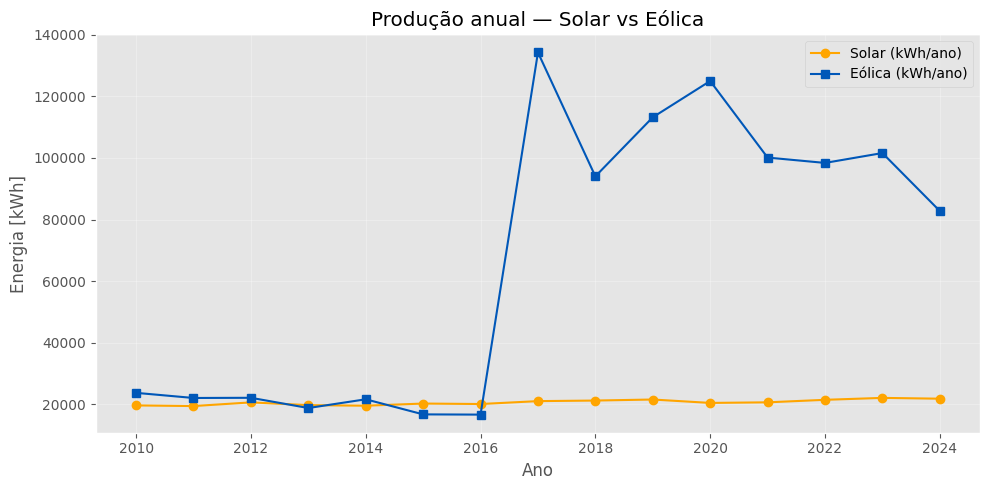

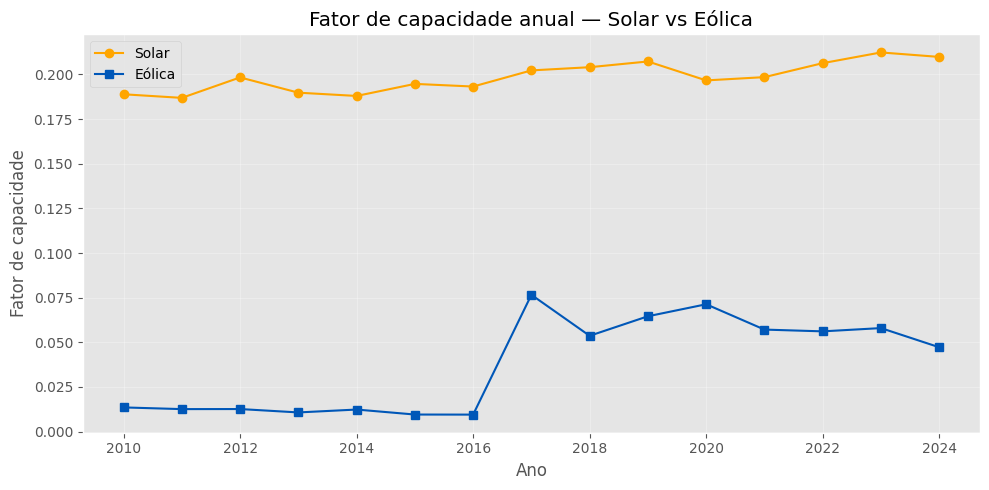

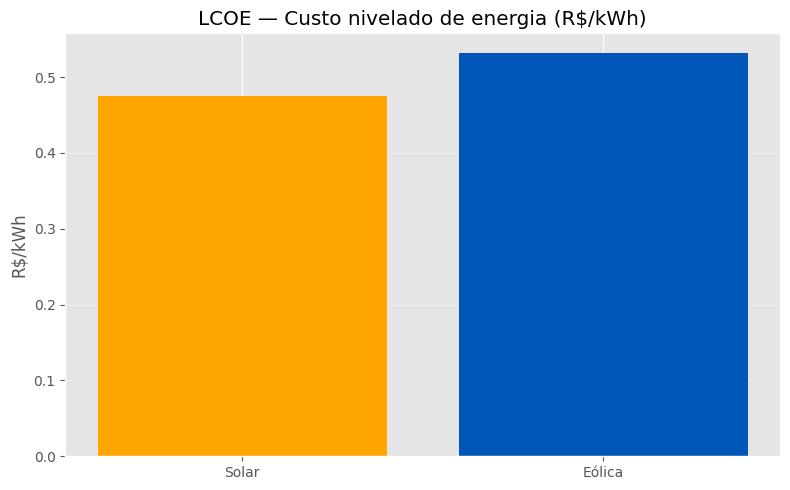

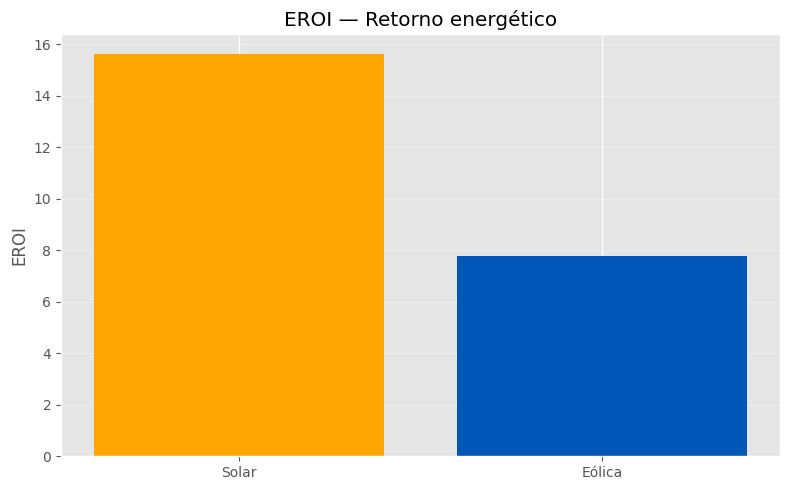

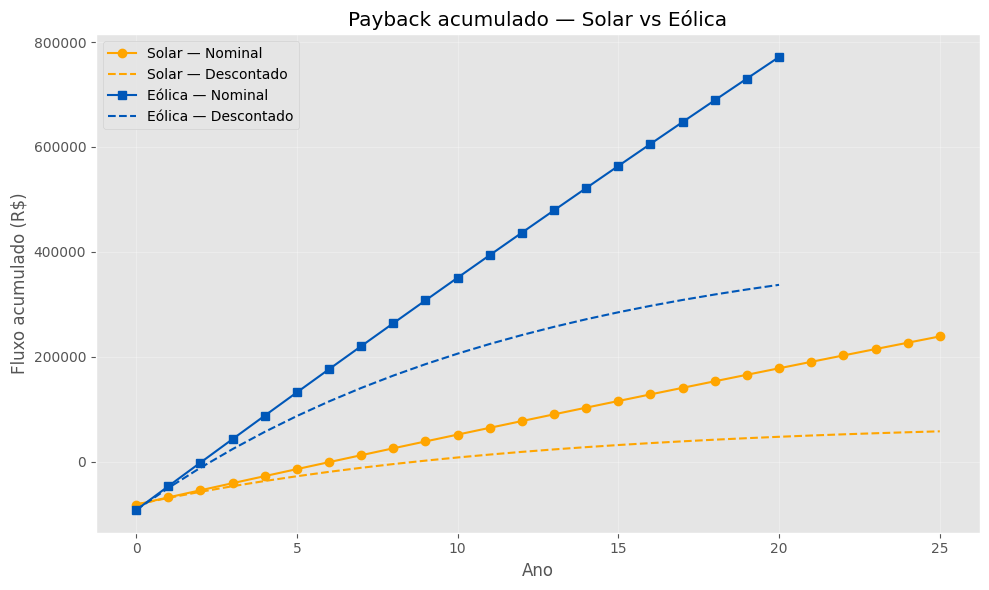

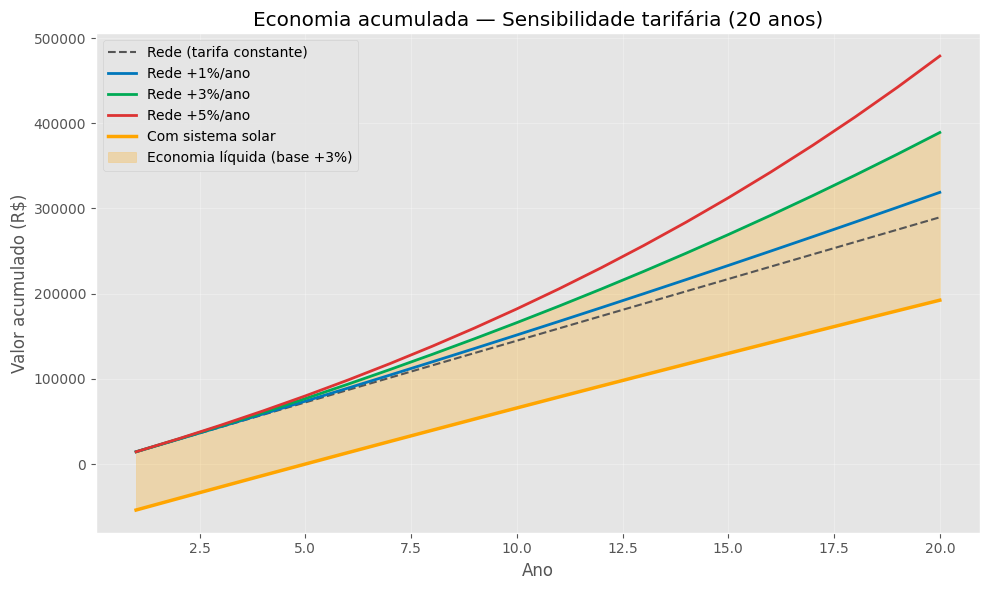

🔹 Economia líquida estimada em 20 anos (cenário +3%/ano): R$ 47,248.45
💰 SOLAR — ROI líquido em 25 anos: 291.02%  (Lucro total: R$ 238,632.61)
💰 EÓLICA — ROI líquido em 20 anos: 834.24%  (Lucro total: R$ 771,501.96)


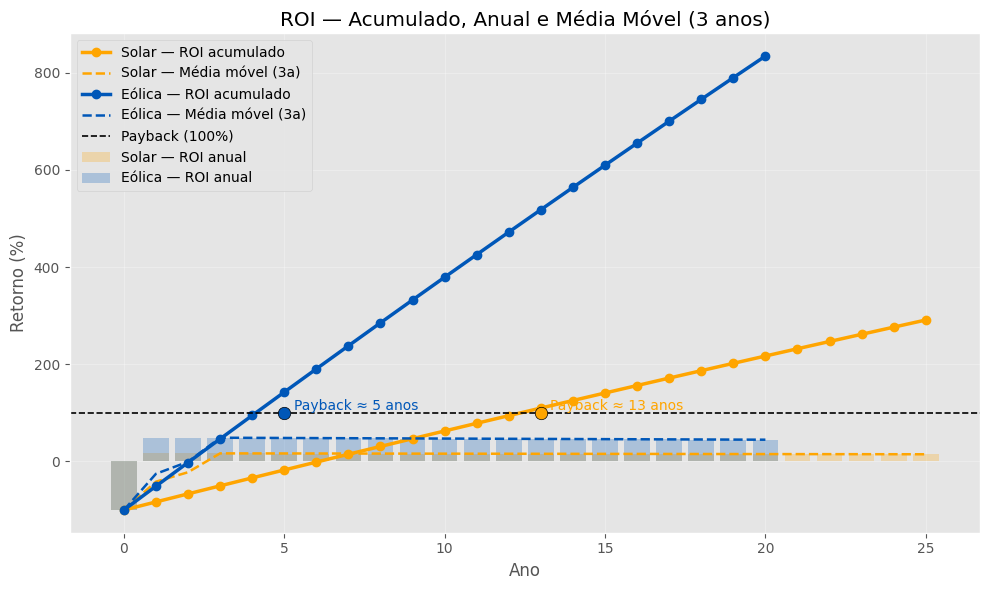

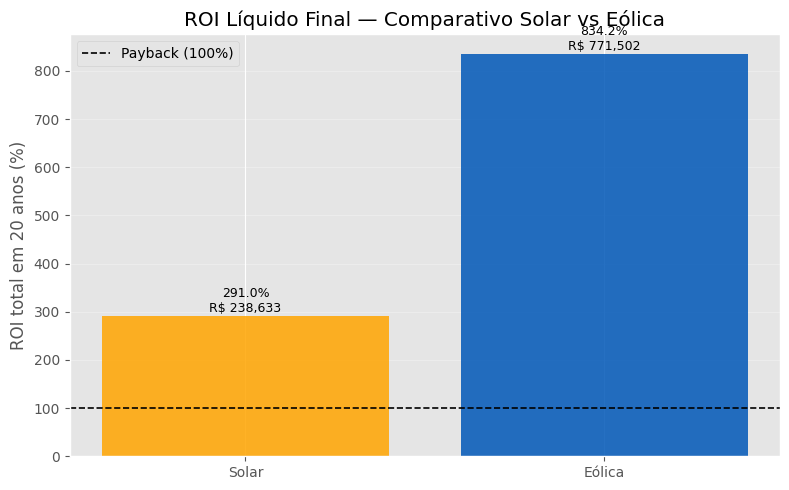

INFO:energy_analysis:Recomendação final: SOLAR (confiança: 27.47%)


In [334]:
# ================================================================
# SANITIZAÇÃO FINAL (TZ/ordenamento) — assinatura preservada
# ================================================================
def _sanitize_date(df: pd.DataFrame, timezone: str) -> pd.DataFrame:
    """
    Normaliza e blinda o dataframe contra ambiguidades em 'date' e índice temporal.
    Preserva interface.
    """
    out = ensure_no_date_ambiguity(df.copy())

    # Se índice for DatetimeIndex, trazer para coluna 'date'
    if isinstance(out.index, pd.DatetimeIndex):
        try:
            idx = out.index.tz_convert(timezone)
        except Exception:
            idx = out.index
        out["date"] = pd.to_datetime(idx)
        out.reset_index(drop=True, inplace=True)

    # Normaliza 'date'
    if "date" in out.columns:
        out["date"] = pd.to_datetime(out["date"], errors="coerce")
        out = ensure_no_date_ambiguity(out)

    out["date"] = out["date"].dt.tz_localize(None).dt.floor("h")
    out.sort_values("date", inplace=True)
    out["ano"] = out["date"].dt.year
    return ensure_no_date_ambiguity(out)


# ============================================================
# MAIN — fluxo físico, econômico e decisório
# ============================================================
if __name__ == "__main__":

     # 🔧 Reconfiguração do logger — garante funcionamento mesmo isolado
    logging.basicConfig(
        level=logging.INFO,               # Mostra INFO, WARNING, ERROR
        format="%(asctime)s | %(levelname)s | %(message)s",
        datefmt="%H:%M:%S"
    )

    logger = logging.getLogger("energy_analysis")
    logger.setLevel(logging.INFO)

    #latitude, longitude = -29.9200000, -50.2700000
    latitude, longitude = -12.9618813, -38.5000007
    start_date, end_date = "2010-01-01", "2025-01-01"
    timezone = "America/Sao_Paulo"

    logger.info("=== Início da execução principal ===")

    hourly_data = search_info_weather(
        latitude, longitude, start_date, end_date, timezone,
        cache_path=".cache", cache_expire_hours=24, normalize=True
    )
    df = _sanitize_date(pd.DataFrame(hourly_data["data"]), timezone)
    if df.empty:
        raise RuntimeError("Sem dados climáticos válidos.")

    # Variabilidade → incertezas σ
    rad = df.groupby("ano")["shortwave_radiation"].mean()
    wind = df.groupby("ano")["wind_speed_10m"].mean()
    cv_rad = rad.std() / rad.mean() if rad.mean() else 0
    cv_wind = wind.std() / wind.mean() if wind.mean() else 0
    n_anos = len(rad)
    se_rad, se_wind = cv_rad / np.sqrt(n_anos), cv_wind / np.sqrt(n_anos)
    sigma_lcoe = {"solar": se_rad * 0.5, "eolica": se_wind * 0.5}
    sigma_eroi = {"solar": se_rad, "eolica": se_wind}
    sigma_fc = {"solar": se_rad, "eolica": se_wind}

    # === Produção Solar e Eólica ===
    solar_data = calcular_producao_e_fator_capacidade_anual(df, "solar", painel=PAINEL_SOLAR)
    eolica_data = calcular_producao_e_fator_capacidade_anual(df, "eolica", turbina=TURBINA_EOLICA)
    prod_s, fc_s = solar_data[2], solar_data[3]
    prod_e, fc_e = eolica_data[2], eolica_data[3]

    # LCOE, EROI e Payback (mantidos conforme refatorações anteriores)
    lcoe_solar = calcular_lcoe(
        solar_data[0],
        PAINEL_SOLAR["custo_equipamento"] * PAINEL_SOLAR["quantidade_paineis"],
        PAINEL_SOLAR["custo_instalacao"] * PAINEL_SOLAR["quantidade_paineis"],
        PAINEL_SOLAR["vida_util"],
        potencia_kw=PAINEL_SOLAR["potencia_kwp"] * PAINEL_SOLAR["quantidade_paineis"],
        fonte="solar"
    )
    lcoe_eolica = calcular_lcoe(
        eolica_data[0],
        TURBINA_EOLICA["custo_equipamento"] * TURBINA_EOLICA["quantidade_turbinas"],
        TURBINA_EOLICA["custo_instalacao"] * TURBINA_EOLICA["quantidade_turbinas"],
        TURBINA_EOLICA["vida_util"],
        potencia_kw=TURBINA_EOLICA["potencia_nominal"] * TURBINA_EOLICA["quantidade_turbinas"],
        fonte="eolica"
    )
    eroi_solar = calcular_eroi(
        potencia_kw=PAINEL_SOLAR["potencia_kwp"] * PAINEL_SOLAR["quantidade_paineis"],
        producao_anual_kwh=prod_s,
        vida_util=PAINEL_SOLAR["vida_util"],
        fonte="solar"
    )
    eroi_eolica = calcular_eroi(
        potencia_kw=TURBINA_EOLICA["potencia_nominal"] * TURBINA_EOLICA["quantidade_turbinas"],
        producao_anual_kwh=prod_e,
        vida_util=TURBINA_EOLICA["vida_util"],
        fonte="eolica"
    )

    # Payback Solar
    payback_solar = calcular_payback(
        capex_total=PAINEL_SOLAR["custo_equipamento"] * PAINEL_SOLAR["quantidade_paineis"]
                    + PAINEL_SOLAR["custo_instalacao"] * PAINEL_SOLAR["quantidade_paineis"],   # 🔧 CAPEX total em R$
        producao_anual_kwh=solar_data[2],        # média anual de produção (52457.05 kWh/ano)
        tarifa_r_kwh=0.70,                       # valor de venda/compensação por kWh
        vida_util=PAINEL_SOLAR["vida_util"],     # 25 anos
        degradacao_anual=0.005,                  # 0,5% de degradação anual
        om_fixo_anual=0.0,
        om_percentual=0.01,                      # 1% do CAPEX/ano
        taxa_desconto=0.08,
        fonte="solar"
    )


    # Payback Eólico
    payback_eolica = calcular_payback(
        capex_total=TURBINA_EOLICA["custo_equipamento"] * TURBINA_EOLICA["quantidade_turbinas"]
                    + TURBINA_EOLICA["custo_instalacao"] * TURBINA_EOLICA["quantidade_turbinas"],  # 🔧 CAPEX total em R$
        producao_anual_kwh=eolica_data[2],       # média anual de produção (3304.03 kWh/ano)
        tarifa_r_kwh=0.70,
        vida_util=TURBINA_EOLICA["vida_util"],   # 20 anos
        degradacao_anual=0.005,
        om_fixo_anual=0.0,
        om_percentual=0.01,
        taxa_desconto=0.08,
        fonte="eolica"
    )

    # Decisão final
    resultado = definir_melhor_energia(
        solar_lcoe=lcoe_solar["LCOE_R$/kWh"],
        eolica_lcoe=lcoe_eolica["LCOE_R$/kWh"],
        solar_eroi=eroi_solar if isinstance(eroi_solar, float) else eroi_solar["EROI"],
        eolica_eroi=eroi_eolica if isinstance(eroi_eolica, float) else eroi_eolica["EROI"],
        solar_fc=fc_s, eolica_fc=fc_e,
        payback_solar=payback_solar, payback_eolica=payback_eolica,
        sigma_lcoe=sigma_lcoe, sigma_eroi=sigma_eroi, sigma_fc=sigma_fc
    )

    # Visualização
    gerar_graficos(
        producao_solar_anual=solar_data[0],
        producao_eolica_anual=eolica_data[0],
        fatores_capacidade_solar=solar_data[1],
        fatores_capacidade_eolica=eolica_data[1],
        lcoe_solar_rpkwh=lcoe_solar["LCOE_R$/kWh"],
        lcoe_eolica_rpkwh=lcoe_eolica["LCOE_R$/kWh"],
        eroi_solar=eroi_solar,
        eroi_eolica=eroi_eolica,
        payback_solar=payback_solar,
        payback_eolica=payback_eolica,
        tarifa_r_kwh=0.7,
        horizonte_anos=20
    )


    logger.info(f"Recomendação final: {resultado['recomendacao'].upper()} (confiança: {resultado['confidence']:.2f}%)")